<a href="https://colab.research.google.com/github/swathi023/git-marathon/blob/main/regarssionproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [ ]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


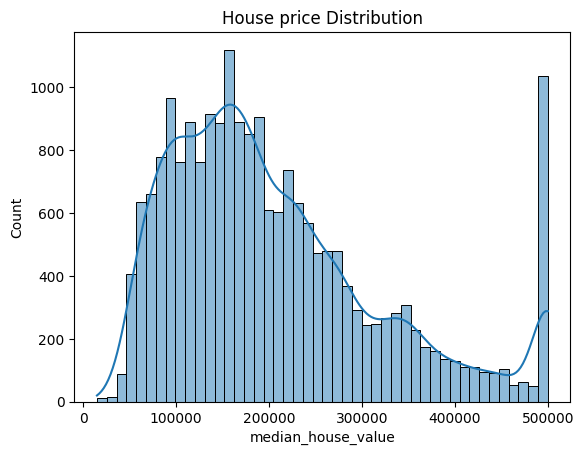

In [ ]:
sns.histplot(df['median_house_value'],kde= True)
plt.title("House price Distribution")
plt.show()

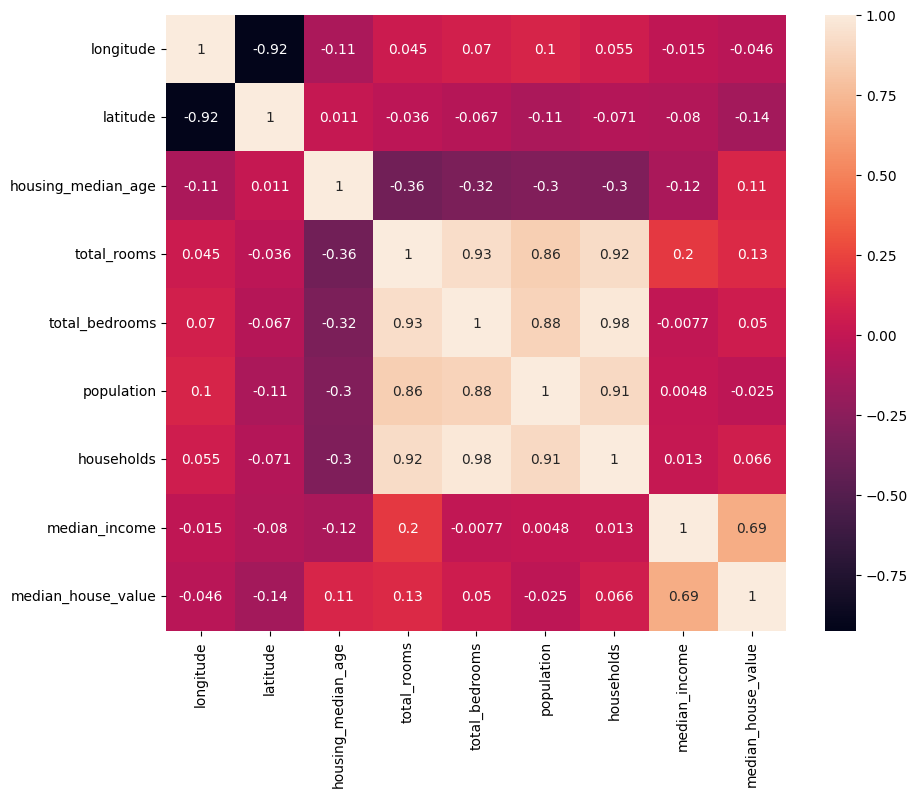

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True) #correlation in which it checks the relation between the data set
plt.show()

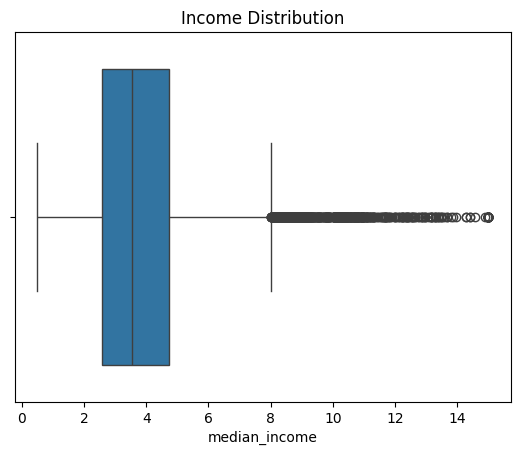

In [ ]:
sns.boxplot(x=df['median_income'])
plt.title("Income Distribution")
plt.show()


In [ ]:
FEATURES ENGINEERING

In [ ]:
df['rooms_per_household'] = df['total_rooms']/df['households']
df['bedrooms_per_room'] = df['total_bedrooms']/df['total_rooms']
df['population_per_household'] = df['population']/df['households']



In [ ]:
if 'ocean_proximity' in df.columns:

  df = pd.get_dummies(df,columns=['ocean_proximity'])

In [ ]:
x = df.drop('median_house_value',axis=1)
y = df['median_house_value']

In [ ]:
scaler = StandardScaler()
x = scaler.fit_transform(x)


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [ ]:
model = RandomForestRegressor()
model.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 31852.472175387593


In [ ]:
mae = mean_squared_error(y_test,y_pred)
print("MSE:",mae)

MSE: 2445582958.5165358


In [ ]:
rmse = np.sqrt(mae)
print("RMSE:", rmse)

RMSE: 49452.83569742524


In [ ]:
r2 = r2_score(y_test,y_pred)
print("R2:",r2)

R2: 0.8133725425325229


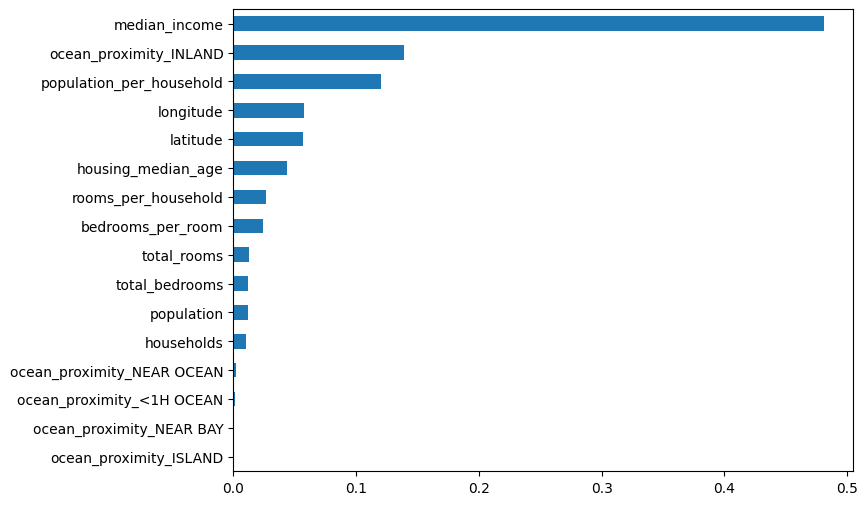

In [ ]:
importance = pd.Series(model.feature_importances_,index=df.drop('median_house_value', axis=1).columns)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.show()

In [ ]:
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [5,10,20]
}
grid = GridSearchCV(RandomForestRegressor(),param_grid,cv=5)
grid.fit(x_train,y_train)
best_model = grid.best_estimator_
print("best parameters:",grid.best_params_)

best parameters: {'max_depth': 20, 'n_estimators': 100}


In [ ]:
y_pred = best_model.predict(x_test)
print("R2:",r2_score(y_test, y_pred_best ))